Following from CONUS_setup, which compiles the national data for modelling, this notebook imports the master dataset and starts the actual modelling.
- Start by checking just FL to ensure we get the same results as when we were analysing just FL. Then we can run the same code on the full CONUS dataset and see how it performs.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

master_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

event_FL_df = pd.read_parquet(master_path)

event_FL_df["CountyFIPS"] = event_FL_df["CountyFIPS"].astype(str).str.zfill(5)
event_FL_df["event_start"] = pd.to_datetime(event_FL_df["event_start"])

# Florida replication subset from the CONUS master table
event_FL_df = event_FL_df[event_FL_df["CountyFIPS"].str.startswith("12")].copy()

# Make sure the target column name matches the old notebook convention
if "t90" not in event_FL_df.columns and "t90_lastcross" in event_FL_df.columns:
    event_FL_df["t90"] = event_FL_df["t90_lastcross"]

print("Florida subset shape:", event_FL_df.shape)
print("Columns:")
print(event_FL_df.columns.tolist())
print(event_FL_df.head().to_string(index=False))

Florida subset shape: (90, 42)
Columns:
['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 't90_lastcross', 'censored_lastcross', 'crossing_time_lastcross', 't50', 't50_censored', 'peak_outage_clean_t50', 'threshold_used_t50', 'crossing_time_t50', 'max_outage_raw', 'hours_above_thresh_raw', 'n_ts_points', 'is_valid', 't90', 't90_censored', 'peak_outage_clean']
                 event_id         storm CountyFIPS    county         event_start  duration_hours  county_pop  pre_outage_tracked_customers  days_since_d

In [39]:
# -----------------------
# RF_v4 feature set
# -----------------------

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_col = "t90"
group_col = "storm"

X = event_FL_df[features_v4].copy()
y = event_FL_df[target_col].copy()
groups = event_FL_df[group_col].copy()

print("Missing values by feature:")
print(X.isna().sum())

print("\nFeature preview:")
print(X.head())

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])


logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)

    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4_fl, fold_v4_fl, mae_v4_fl, rmse_v4_fl = evaluate_logo_global(model_v4, X, y, groups)

print("RF_v4-inspired global metrics:")
print("Global MAE:", mae_v4_fl)
print("Global RMSE:", rmse_v4_fl)

print("\nPer-storm diagnostics:")
print(fold_v4_fl.sort_values("mae_diagnostic_per_storm", ascending=False))

Missing values by feature:
max_gust                           0
mean_gust_7d                       0
total_precip_7d                    0
pressure_min_7d                    0
county_pop                         0
min_dist_to_storm_km               0
storm_max_wind_near_conus_mps      0
county_gdp_real_2017_dollars       0
county_gdp_real_2017_per_capita    0
dtype: int64

Feature preview:
     max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
1   12.601287      7.421799        67.413998      1009.864246       45260   
21  27.279316     12.005697        92.750718       995.318712       12498   
22  33.241034      9.333728       153.916280       982.833530        7786   
23  25.291777     14.104932        89.230104       996.010565       13464   
24  33.169058      9.553964       145.733609       976.919507       45260   

    min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
1              31.525385                       25.72220   
21            169.092475    

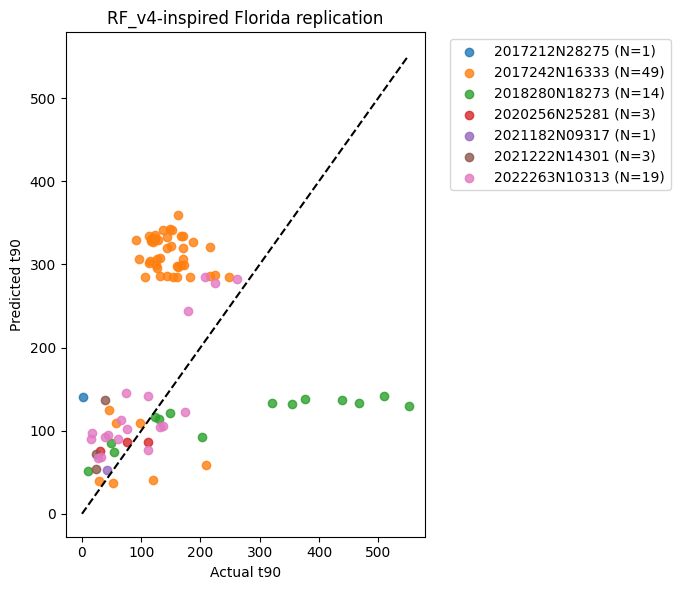

In [ ]:
def plot_scatter_by_storm(
    preds,
    data_df,
    title,
    target_col="t90",
    group_col="storm",
    max_legend_storms=15,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    preds = np.asarray(preds)
    if len(preds) != len(data_df):
        raise ValueError(
            f"Length mismatch: preds has length {len(preds)} but data_df has length {len(data_df)}"
        )

    plot_df = data_df[[group_col, target_col]].copy()
    plot_df["pred"] = preds

    # Keep the old appearance order when there are only a few storms.
    storms_in_order = list(plot_df[group_col].dropna().unique())
    storm_counts = plot_df[group_col].value_counts(dropna=False)

    # Use the default matplotlib color cycle so the style stays familiar.
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    plt.figure(figsize=(7, 6))

    if len(storms_in_order) <= max_legend_storms:
        # Original behavior: one color per storm, in appearance order.
        for i, storm in enumerate(storms_in_order):
            s = plot_df[group_col] == storm
            plt.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, "pred"],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )
    else:
        # Top 10 storms by number of events, then one "Other" category.
        top_storms = storm_counts.head(max_legend_storms).index.tolist()
        other_mask = ~plot_df[group_col].isin(top_storms)

        for i, storm in enumerate(top_storms):
            s = plot_df[group_col] == storm
            plt.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, "pred"],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )

        if other_mask.any():
            plt.scatter(
                plot_df.loc[other_mask, target_col],
                plot_df.loc[other_mask, "pred"],
                label=f"Other (N={int(other_mask.sum())})",
                alpha=0.5,
                color="gray",
            )

    m = max(plot_df[target_col].max(), np.nanmax(plot_df["pred"]))
    plt.plot([0, m], [0, m], "--", color="black")

    plt.xlabel(f"Actual {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_scatter_by_storm(pred_v4_fl, event_FL_df, "RF_v4-inspired Florida replication")

Investigating missing events:

In [41]:
print(event_FL_df.shape)
print(event_FL_df[event_FL_df["CountyFIPS"].str.startswith("12")].shape)

(90, 42)
(90, 42)


Investigating why RF_v4 gives slightly different results than the above

In [42]:
# --- Load and normalize the old RF_v4 table and the current FL replication table ---

import pandas as pd
import numpy as np

rf_v4_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv"

rf_v4_df = pd.read_csv(rf_v4_path)

# Standardize key fields
rf_v4_df["CountyFIPS"] = rf_v4_df["CountyFIPS"].astype(str).str.zfill(5)
rf_v4_df["event_start"] = pd.to_datetime(rf_v4_df["event_start"], errors="coerce")

event_FL_df = event_FL_df.copy()
event_FL_df["CountyFIPS"] = event_FL_df["CountyFIPS"].astype(str).str.zfill(5)
event_FL_df["event_start"] = pd.to_datetime(event_FL_df["event_start"], errors="coerce")

# Use CountyFIPS + event_start as the comparison key, since event_id conventions differ
rf_v4_df["compare_key"] = (
    rf_v4_df["CountyFIPS"].astype(str) + "_" +
    rf_v4_df["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

event_FL_df["compare_key"] = (
    event_FL_df["CountyFIPS"].astype(str) + "_" +
    event_FL_df["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

print("Loaded RF_v4 shape:", rf_v4_df.shape)
print("Loaded current FL shape:", event_FL_df.shape)

print("\nRF_v4 columns:")
print(rf_v4_df.columns.tolist())

print("\nCurrent FL columns:")
print(event_FL_df.columns.tolist())

print("\nRF_v4 compare keys head:")
print(rf_v4_df[["event_id", "CountyFIPS", "event_start", "compare_key"]].head().to_string(index=False))

print("\nCurrent FL compare keys head:")
print(event_FL_df[["event_id", "CountyFIPS", "event_start", "compare_key"]].head().to_string(index=False))

Loaded RF_v4 shape: (90, 20)
Loaded current FL shape: (90, 43)

RF_v4 columns:
['event_id', 'storm', 'CountyFIPS', 't90', 't90_censored', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'max_customers_tracked', 'county_pop', 'event_start', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 'year', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'compare_key']

Current FL columns:
['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_m

In [43]:
# --- Compare old RF_v4 table vs current FL replication table using CountyFIPS + event_start ---

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_cols = ["t90"]

old_cols = ["compare_key"] + [c for c in features_v4 + target_cols if c in rf_v4_df.columns]
new_cols = ["compare_key"] + [c for c in features_v4 + target_cols if c in event_FL_df.columns]

merged = event_FL_df[new_cols].merge(
    rf_v4_df[old_cols],
    on="compare_key",
    how="outer",
    suffixes=("_new", "_old"),
    indicator=True
)

print("Row set comparison:")
print(merged["_merge"].value_counts())

only_new = merged.loc[merged["_merge"] == "left_only", ["compare_key"]]
only_old = merged.loc[merged["_merge"] == "right_only", ["compare_key"]]

print("\nRows only in current FL table:")
print(only_new.to_string(index=False))

print("\nRows only in old RF_v4 table:")
print(only_old.to_string(index=False))

shared = merged.loc[merged["_merge"] == "both"].copy()
print("\nShared rows:", len(shared))

# Compare features on shared rows
compare_rows = []
for feat in features_v4 + target_cols:
    new_col = f"{feat}_new"
    old_col = f"{feat}_old"

    if new_col not in shared.columns or old_col not in shared.columns:
        continue

    a = shared[new_col]
    b = shared[old_col]

    same = (a.isna() & b.isna()) | (a.eq(b))
    exact_match_rate = float(same.mean())

    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        diff = (a - b).abs()
        mean_abs_diff = float(diff.mean())
        max_abs_diff = float(diff.max())
    else:
        mean_abs_diff = np.nan
        max_abs_diff = np.nan

    compare_rows.append({
        "feature": feat,
        "exact_match_rate": exact_match_rate,
        "mean_abs_diff": mean_abs_diff,
        "max_abs_diff": max_abs_diff,
        "n_missing_new": int(a.isna().sum()),
        "n_missing_old": int(b.isna().sum()),
    })

compare_df = pd.DataFrame(compare_rows)

print("\nFeature comparison on shared rows:")
print(compare_df.to_string(index=False))

# Show the rows that differ most overall
if len(shared) > 0:
    diff_score = np.zeros(len(shared), dtype=float)

    for feat in features_v4 + target_cols:
        nc = f"{feat}_new"
        oc = f"{feat}_old"
        if nc in shared.columns and oc in shared.columns:
            if pd.api.types.is_numeric_dtype(shared[nc]) and pd.api.types.is_numeric_dtype(shared[oc]):
                diff_score += (shared[nc] - shared[oc]).abs().fillna(0).to_numpy()

    shared = shared.assign(total_abs_diff=diff_score)

    print("\nTop 10 most different shared rows:")
    print(
        shared.sort_values("total_abs_diff", ascending=False)[
            ["compare_key", "total_abs_diff"]
        ].head(10).to_string(index=False)
    )

Row set comparison:
_merge
both          90
left_only      0
right_only     0
Name: count, dtype: int64

Rows only in current FL table:
Empty DataFrame
Columns: [compare_key]
Index: []

Rows only in old RF_v4 table:
Empty DataFrame
Columns: [compare_key]
Index: []

Shared rows: 90

Feature comparison on shared rows:
                        feature  exact_match_rate  mean_abs_diff  max_abs_diff  n_missing_new  n_missing_old
                       max_gust          0.966667   1.184238e-16  3.552714e-15              0              0
                   mean_gust_7d          0.855556   2.565849e-16  1.776357e-15              0              0
                total_precip_7d          0.833333   4.519841e-15  5.684342e-14              0              0
                pressure_min_7d          1.000000   0.000000e+00  0.000000e+00              0              0
                     county_pop          1.000000   0.000000e+00  0.000000e+00              0              0
           min_dist_to_storm

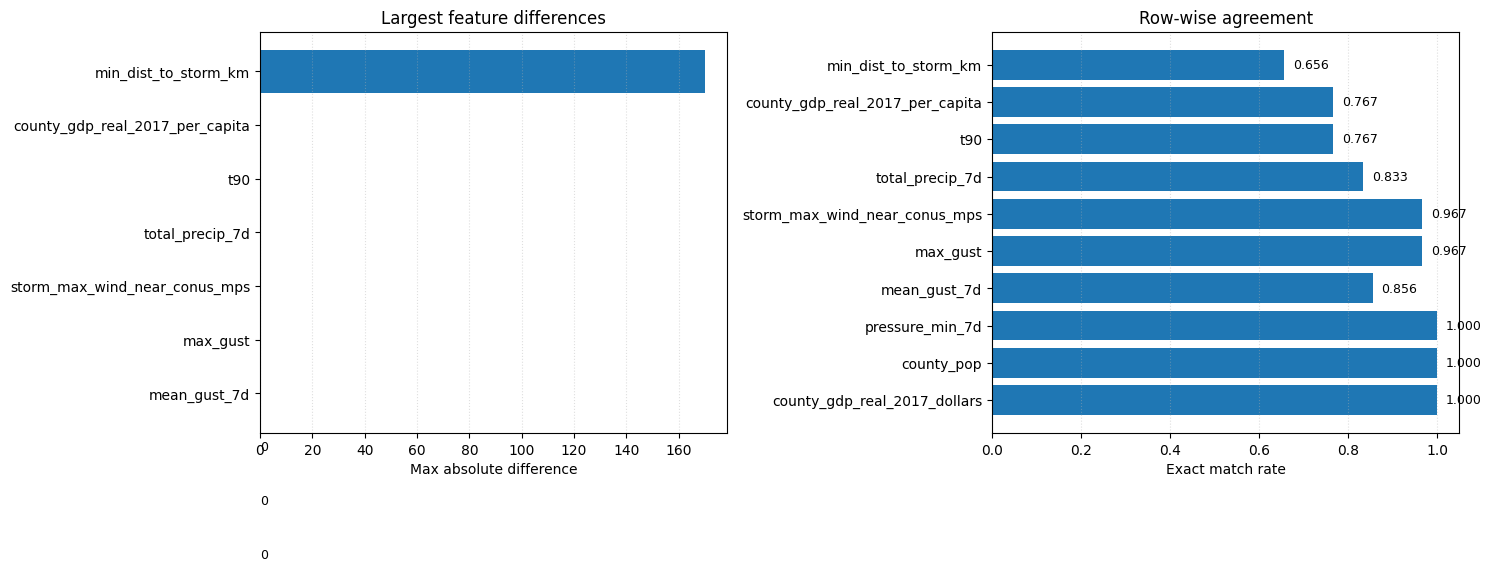

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Work on a copy so we can safely order and handle zeros
plot_df = compare_df.copy()

# Order by max absolute difference, largest first
plot_df = plot_df.sort_values("max_abs_diff", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: max absolute difference on a log scale ---
vals = plot_df["max_abs_diff"].to_numpy(dtype=float)
vals_plot = np.where(vals > 0, vals, np.nan)

axes[0].barh(plot_df["feature"], vals_plot)
# axes[0].set_xscale("log")
axes[0].invert_yaxis()
# axes[0].set_xlabel("Max absolute difference (log scale)")
axes[0].set_xlabel("Max absolute difference")

axes[0].set_title("Largest feature differences")
axes[0].grid(True, axis="x", which="both", linestyle=":", alpha=0.4)

# Add labels for exact zeros so they are visible
for i, v in enumerate(vals):
    if v == 0:
        axes[0].text(1e-18, i, "0", va="center", ha="left", fontsize=9)

# --- Panel 2: exact match rate ---
axes[1].barh(plot_df["feature"], plot_df["exact_match_rate"])
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("Exact match rate")
axes[1].set_title("Row-wise agreement")
axes[1].grid(True, axis="x", linestyle=":", alpha=0.4)

for i, v in enumerate(plot_df["exact_match_rate"]):
    axes[1].text(min(v + 0.02, 1.02), i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

So theres somewhat of a difference for min distance; up to 12 km?

------------------ **FULL CONUS RF:** -------------------

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

# Load the CONUS master table
master_candidates = [
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master.parquet",
]

master_path = next((p for p in master_candidates if __import__("os").path.exists(p)), None)
if master_path is None:
    raise FileNotFoundError("No CONUS master parquet found in the expected locations.")

event_df = pd.read_parquet(master_path)
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["event_start"] = pd.to_datetime(event_df["event_start"])

if "t90" not in event_df.columns and "t90_lastcross" in event_df.columns:
    event_df["t90"] = event_df["t90_lastcross"]

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

missing_features = [c for c in features_v4 if c not in event_df.columns]
if missing_features:
    raise KeyError(f"Missing expected features: {missing_features}")

event_df = event_df.dropna(subset=["t90"]).copy()

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

print("Using master file:", master_path)
print("Event shape:", event_df.shape)
print("Missing values by feature:")
print(X.isna().sum())

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])

logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4_conus, fold_v4_conus, mae_v4_conus, rmse_v4_conus = evaluate_logo_global(model_v4, X, y, groups)

print("\nRF global metrics:")
print("Global MAE:", mae_v4)
print("Global RMSE:", rmse_v4)

print("\nPer-storm diagnostics:")
print(fold_v4.sort_values("mae_diagnostic_per_storm", ascending=False))

Using master file: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet
Event shape: (913, 42)
Missing values by feature:
max_gust                            0
mean_gust_7d                        0
total_precip_7d                     0
pressure_min_7d                     0
county_pop                          0
min_dist_to_storm_km                0
storm_max_wind_near_conus_mps       0
county_gdp_real_2017_dollars       18
county_gdp_real_2017_per_capita    18
dtype: int64

RF global metrics:
Global MAE: 47.21870831353867
Global RMSE: 78.99450095493896

Per-storm diagnostics:
    fold          storm    n  mae_diagnostic_per_storm  \
2      3  2017228N14314   19                103.701455   
24    25  2021239N17281   39                 97.432967   
3      4  2017242N16333  127                 92.511007   
6      7  2018242N13343   40                 75.070760   
7      8  2018280N18273  152                 62.142949   
9   

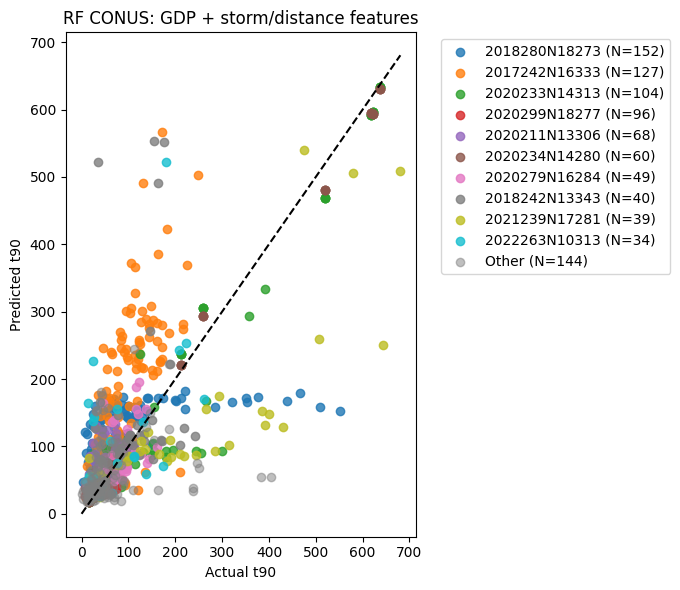

In [46]:
plot_scatter_by_storm(pred_v4_conus, event_df, "RF CONUS: GDP + storm/distance features")

CONUS LOSO mean baseline:
Global MAE: 78.87805805789709
Global RMSE: 127.65166740772119

Per-storm diagnostics:
    fold          storm    n  mae_diagnostic_per_storm  \
16    17  2020234N14280   60                184.047233   
24    25  2021239N17281   39                157.721072   
15    16  2020233N14313  104                136.613355   
2      3  2017228N14314   19                 96.518642   
1      2  2017212N28275    1                 95.341718   
10    11  2019291N22264    1                 93.464174   
0      1  2017171N24271    1                 84.559252   
4      5  2017277N11279    4                 70.911752   
20    21  2021169N23268    1                 69.809807   
5      6  2018146N19273    8                 69.211839   
11    12  2019299N25265   20                 68.308055   
27    28  2022263N10313   34                 67.530148   
21    22  2021182N09317    2                 66.968126   
7      8  2018280N18273  152                 66.816175   
22    23  2021222N

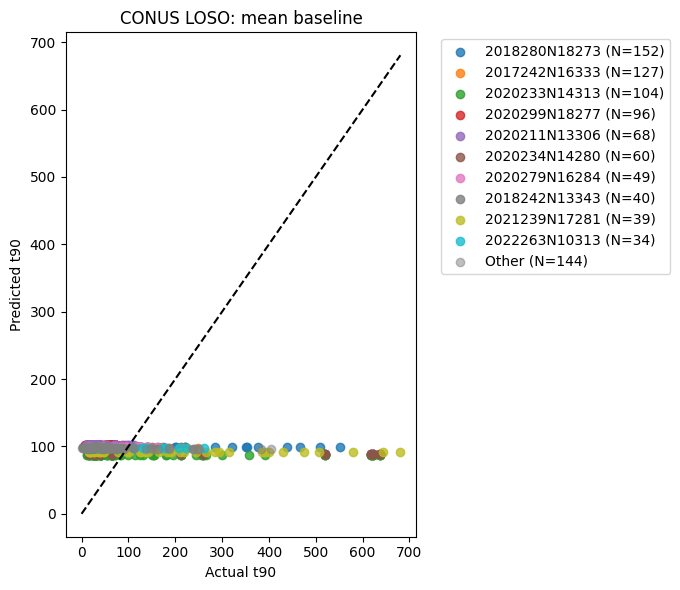

In [47]:
# --- CONUS LOSO mean baseline ---

import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

logo = LeaveOneGroupOut()

def evaluate_mean_logo(y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(np.zeros(len(y)), y, groups), start=1):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        y_pred = np.full(len(test_idx), float(y_train.mean()))
        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_mean, fold_mean, mae_mean, rmse_mean = evaluate_mean_logo(y, groups)

print("CONUS LOSO mean baseline:")
print("Global MAE:", mae_mean)
print("Global RMSE:", rmse_mean)

print("\nPer-storm diagnostics:")
print(fold_mean.sort_values("mae_diagnostic_per_storm", ascending=False))

plot_scatter_by_storm(pred_mean, event_df, "CONUS LOSO: mean baseline")

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_mean)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("CONUS LOSO mean baseline metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

CONUS LOSO mean baseline metrics:
MAE:  78.878 hours
RMSE: 127.652 hours
R^2:  -0.031

Normalized metrics:
nMAE / range: 0.116
nMAE / mean:   0.812
nRMSE / std:    1.015
NMSE / var:     1.031


CONUS LOSO mean baseline metrics:
MAE:  78.878 hours
RMSE: 127.652 hours
R^2:  -0.031

Normalized metrics:
nMAE / range: 0.116
nMAE / mean:   0.812
nRMSE / std:    1.015
NMSE / var:     1.031


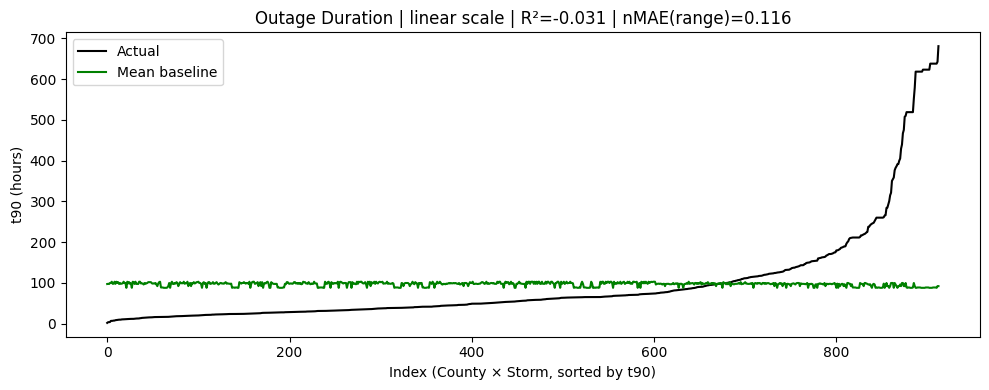

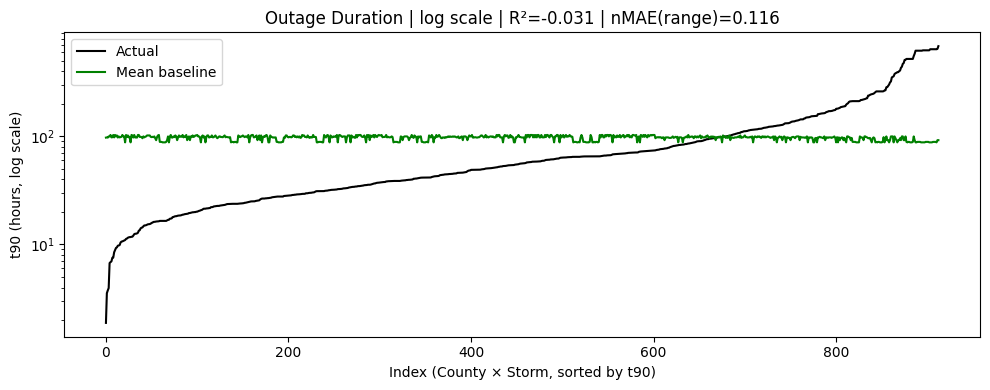

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_mean)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Metrics on the original scale
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("CONUS LOSO mean baseline metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

# Linear scale
plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted, color="black", label="Actual")
plt.plot(x, pred_sorted, color="green", label="Mean baseline")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours)")
plt.title(f"Outage Duration | linear scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# Log scale
eps = 1e-6
y_sorted_log = np.clip(y_sorted, eps, None)
pred_sorted_log = np.clip(pred_sorted, eps, None)

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted_log, color="black", label="Actual")
plt.plot(x, pred_sorted_log, color="green", label="Mean baseline")

plt.yscale("log")
plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours, log scale)")
plt.title(f"Outage Duration | log scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

RF beats Mean!

**Let's now try tuning RF:**

c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total parameter combinations: 36


RF grid search: 100%|██████████| 36/36 [08:12<00:00, 13.67s/it]



Best RF params:
{'rf__max_depth': 20, 'rf__max_features': 0.2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 400}
Best CV global MAE: 36.41600109361899

Tuned RF CONUS LOSO:
Global MAE: 36.41600109361899
Global RMSE: 62.36942042758291

Top 10 parameter sets:
 rf__max_depth  rf__max_features  rf__min_samples_leaf  rf__n_estimators  cv_global_mae  cv_fold_mae_mean
            20               0.2                     1               400      36.416001         29.785407
            20               0.2                     1               200      36.967731         30.532189
            10               0.2                     1               400      37.387827         31.206288
            10               0.2                     1               200      38.150819         31.284454
            20               0.2                     3               200      40.684937         32.748033
            20               0.2                     3               400      40.726794         32.4543

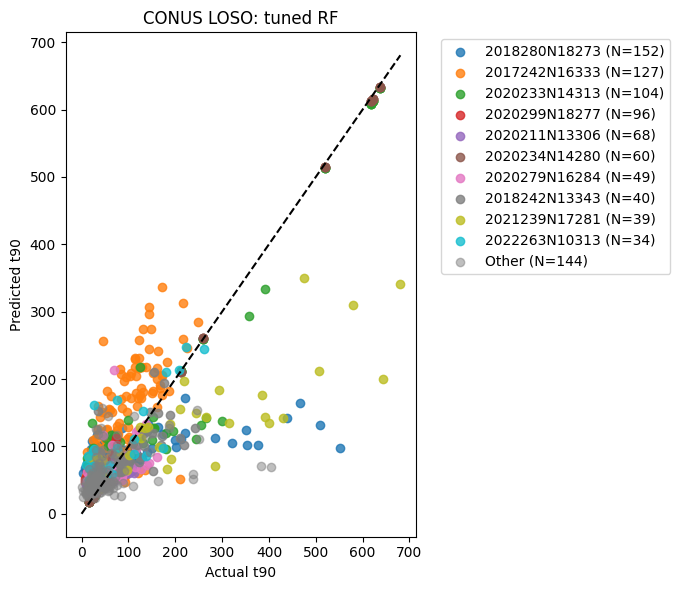

In [48]:
# --- CONUS LOSO tuned RF with progress bar ---

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

logo = LeaveOneGroupOut()
splits = list(logo.split(X, y, groups))

rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(random_state=42))
])

param_grid = {
    # "rf__n_estimators": [200, 400],
    # "rf__max_depth": [None, 10, 20],
    # "rf__min_samples_leaf": [1, 3, 5],
    # "rf__max_features": [0.2, 0.5, 1.0],

    "rf__n_estimators": [200, 400],
    "rf__max_depth": [10, 20],
    "rf__min_samples_leaf": [1, 3, 5],
    "rf__max_features": [0.2, 0.5, 1.0],

}

grid_list = list(ParameterGrid(param_grid))
print(f"Total parameter combinations: {len(grid_list)}")

best_mae = np.inf
best_params = None
best_preds = None
best_fold_df = None

search_rows = []

for params in tqdm(grid_list, desc="RF grid search"):
    fold_preds = np.full(len(y), np.nan)
    fold_rows = []
    fold_maes = []

    for fold_i, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = rf_pipe.set_params(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_preds[test_idx] = y_pred

        fold_mae = mean_absolute_error(y_test, y_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_maes.append(fold_mae)

        fold_rows.append({
            "fold": fold_i,
            "storm": groups.iloc[test_idx].iloc[0],
            "n": len(test_idx),
            "mae_diagnostic_per_storm": fold_mae,
            "rmse_diagnostic_per_storm": fold_rmse,
        })

    global_mae = mean_absolute_error(y, fold_preds)

    search_rows.append({
        **params,
        "cv_global_mae": global_mae,
        "cv_fold_mae_mean": float(np.mean(fold_maes)),
    })

    if global_mae < best_mae:
        best_mae = global_mae
        best_params = params.copy()
        best_preds = fold_preds.copy()
        best_fold_df = pd.DataFrame(fold_rows)

search_df = pd.DataFrame(search_rows).sort_values("cv_global_mae").reset_index(drop=True)

print("\nBest RF params:")
print(best_params)
print("Best CV global MAE:", best_mae)

best_rf = rf_pipe.set_params(**best_params)
pred_rf_tuned, fold_rf_tuned, mae_rf_tuned, rmse_rf_tuned = evaluate_logo_global(
    best_rf, X, y, groups
)

print("\nTuned RF CONUS LOSO:")
print("Global MAE:", mae_rf_tuned)
print("Global RMSE:", rmse_rf_tuned)

print("\nTop 10 parameter sets:")
print(search_df.head(10).to_string(index=False))

print("\nPer-storm diagnostics:")
print(fold_rf_tuned.sort_values("mae_diagnostic_per_storm", ascending=False))


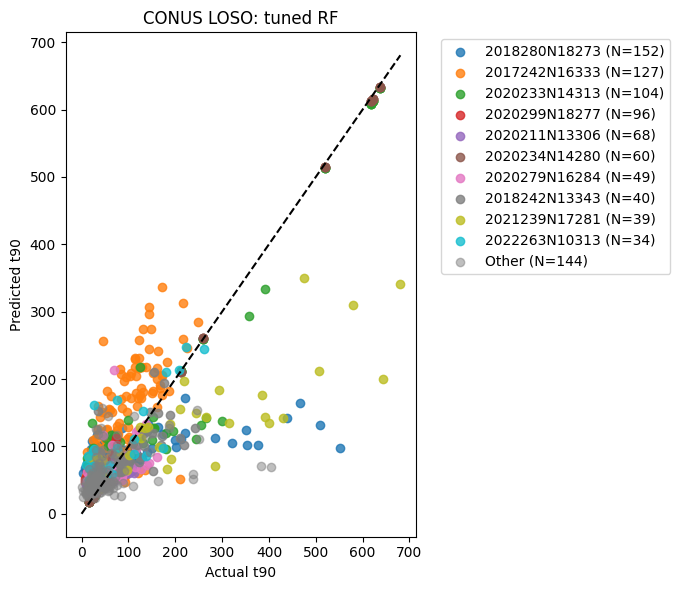

In [49]:
plot_scatter_by_storm(pred_rf_tuned, event_df, "CONUS LOSO: tuned RF")

Tuned RF CONUS R^2: 0.7539153658533576


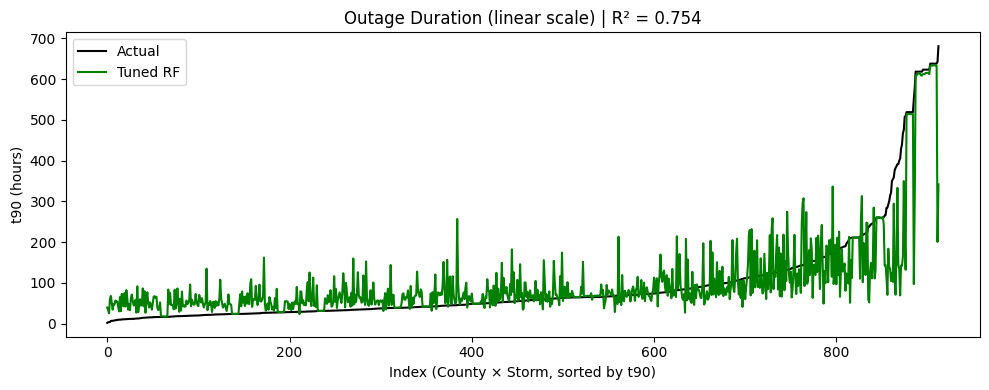

In [ ]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe actually used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_rf_tuned)

# Drop any rows with missing target or prediction
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# R^2
r2 = r2_score(y_true, y_pred)
print("Tuned RF CONUS R^2:", r2)

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted, color="black", label="Actual")
plt.plot(x, pred_sorted, color="green", label="Tuned RF")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours)")
plt.title(f"Outage Duration (linear scale) | R² = {r2:.3f}")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_rf_tuned)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nrmse_iqr = rmse / y_iqr if y_iqr > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("Tuned RF CONUS metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"nRMSE / IQR:    {nrmse_iqr:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

# plt.figure(figsize=(10, 4))
# plt.plot(x, y_sorted, color="black", label="Actual")
# plt.plot(x, pred_sorted, color="green", label="Tuned RF")

# plt.xlabel("Index (County × Storm, sorted by t90)")
# plt.ylabel("t90 (hours)")
# plt.title(
#     f"Outage Duration | R²={r2:.3f} | nMAE(range)={nmae_range:.3f} | nRMSE(std)={nrmse_std:.3f}"
# )
# plt.legend()
# plt.tight_layout()
# plt.show()

Tuned RF CONUS metrics:
MAE:  36.416 hours
RMSE: 62.369 hours
R^2:  0.754

Normalized metrics:
nMAE / range: 0.054
nMAE / mean:   0.375
nRMSE / std:    0.496
nRMSE / IQR:    0.878
NMSE / var:     0.246


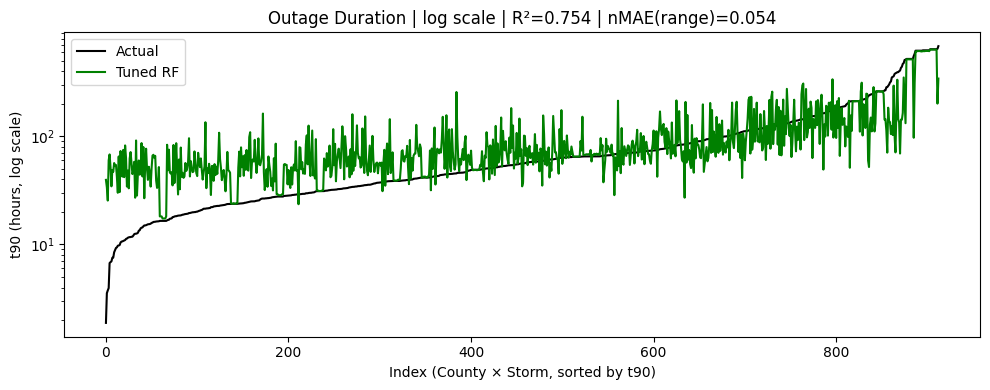

In [53]:
# Log scale: clip at a tiny positive value so the plot is valid if any predictions are <= 0
eps = 1e-6
y_sorted_log = np.clip(y_sorted, eps, None)
pred_sorted_log = np.clip(pred_sorted, eps, None)

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted_log, color="black", label="Actual")
plt.plot(x, pred_sorted_log, color="green", label="Tuned RF")
plt.yscale("log")
plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours, log scale)")
plt.title(f"Outage Duration | log scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

**  NOW FOR MLR, THEN XGB  **